# EXPLORATORY DATA ANALYSIS
## 1. Load Cleaned Data
Import the plotting/analysis libraries and load the four CSV files produced by the data-cleaning notebook: streaming history, playlist, library and the merged tracks summary.



In [ ]:
# Load Cleaned Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

streaming_df = pd.read_csv(r"Data/Cleaned/Streaming_history_cleaned.csv")
playlist_df = pd.read_csv(r"Data/Cleaned/Playlist_cleaned.csv")
library_df = pd.read_csv(r"Data/Cleaned/Library_cleaned.csv")
tracks_df = pd.read_csv(r"Data/Cleaned/Tracks_summary.csv")



## 2. Convert 'endTime' column to datetime format
### Re-parse Date Columns
CSV files don't preserve datetime types, so re-convert every date/time column (`end_time`, `date`, playlist dates, `first_played`, `last_played`) back into proper datetime objects before doing any time-based analysis.

In [25]:
# Convert 'endTime' column to datetime format
streaming_df["end_time"] = pd.to_datetime(streaming_df["end_time"])
streaming_df["date"] = pd.to_datetime(streaming_df["date"])

playlist_df["playlist_last_modified"] = pd.to_datetime(
    playlist_df["playlist_last_modified"],
    errors="coerce"
)

playlist_df["added_date"] = pd.to_datetime(
    playlist_df["added_date"],
    errors="coerce"
)

tracks_df["first_played"] = pd.to_datetime(tracks_df["first_played"], errors="coerce")
tracks_df["last_played"] = pd.to_datetime(tracks_df["last_played"], errors="coerce")

## 3. Data overview
### Dataset Overview and Missing-Value Check
Print the shape and columns of all four tables to confirm they loaded correctly, check each table for missing values and drop any tracks in the master table that are still missing an artist or track name.

In [26]:
# Data overview
print("Streaming Shape:", streaming_df.shape)
print("Playlist Shape:", playlist_df.shape)
print("Library Shape:", library_df.shape)
print("Master track Shape:", tracks_df.shape)

print("\nStreaming Columns:", streaming_df.columns)
print("Playlist Columns:", playlist_df.columns)
print("Library Columns:", library_df.columns)
print("Tracks Columns:", tracks_df.columns)

# Check for missing values
print("\nMissing Values in Streaming Data:\n", streaming_df.isnull().sum())
print("\nMissing Values in Playlist Data:\n", playlist_df.isnull().sum())
print("\nMissing Values in Library Data:\n", library_df.isnull().sum())
print("\nMissing Values in Tracks Data:\n", tracks_df.isnull().sum())

# Drop Missing values in Tracks Data
tracks_df = tracks_df.dropna(subset=["artist_name", "track_name"])
print("\nMissing Values in Tracks Data after dropping:\n", tracks_df.isnull().sum())

Streaming Shape: (8229, 11)
Playlist Shape: (1097, 8)
Library Shape: (302, 6)
Master track Shape: (2205, 10)

Streaming Columns: Index(['end_time', 'artist_name', 'track_name', 'ms_played', 'minutes_played',
       'date', 'year', 'month', 'hour', 'weekday', 'track_key'],
      dtype='str')
Playlist Columns: Index(['playlist_name', 'playlist_last_modified', 'added_date', 'track_name',
       'artist_name', 'album_name', 'track_uri', 'track_key'],
      dtype='str')
Library Columns: Index(['artist_name', 'album_name', 'track_name', 'track_uri', 'track_key',
       'in_library'],
      dtype='str')
Tracks Columns: Index(['track_key', 'artist_name', 'track_name', 'play_count',
       'total_minutes_played', 'first_played', 'last_played', 'playlist_count',
       'playlists', 'in_library'],
      dtype='str')

Missing Values in Streaming Data:
 end_time          0
artist_name       0
track_name        0
ms_played         0
minutes_played    0
date              0
year              0
month  

## 4. Listening Dates Range
### Overall Listening Window and Volume
Find the date range covered by the streaming history (first and last listen) and calculate the total number of minutes/hours listened overall,to get a high-level sense of how much data is being analyzed.


In [28]:
# Listening Dates Range
print("First listen:", streaming_df["end_time"].min())
print("Last listen:", streaming_df["end_time"].max())

# Total Listening Time
total_minutes = streaming_df["minutes_played"].sum()
total_hours = total_minutes / 60

print("Total minutes listened:", round(total_minutes, 2))
print("Total hours listened:", round(total_hours, 2))

First listen: 2025-06-20 20:20:00
Last listen: 2026-06-20 20:02:00
Total minutes listened: 20568.16
Total hours listened: 342.8


## 5. Top Tracks By Play Count
### Most-Played Tracks
Group the streaming history by track and count how many times each song was played, then plot the 15 most-played tracks as a horizontal bar chart (colored by artist) to see clear listening favorites.

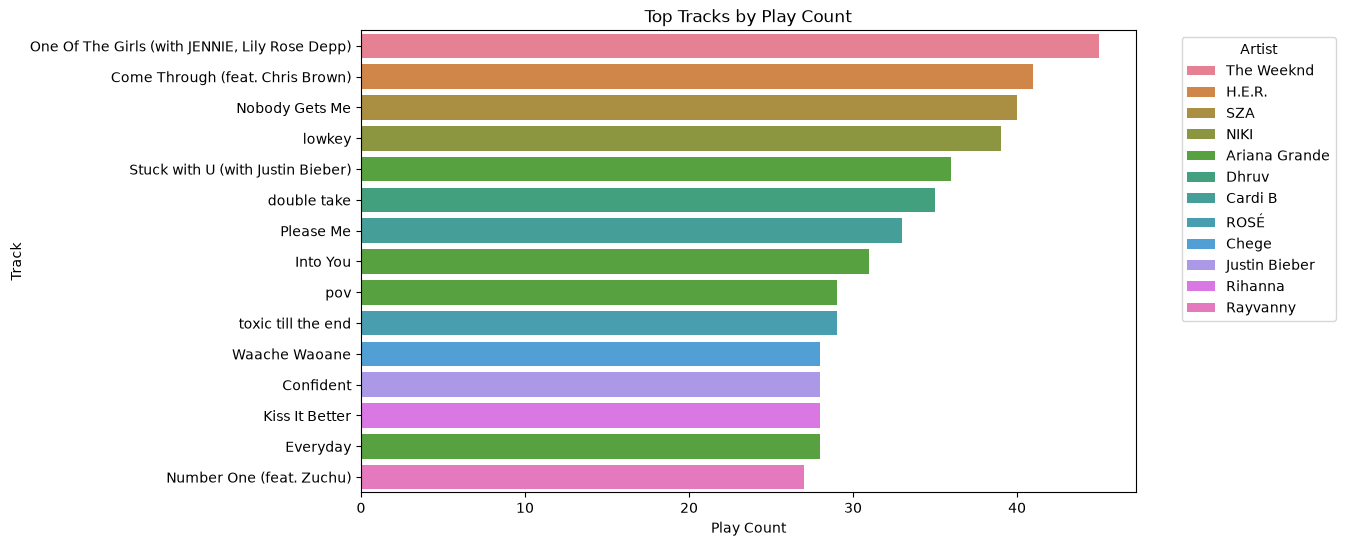

In [30]:
#Top Tracks By Play Count
top_tracks_count = (
    streaming_df
    .groupby(["track_name", "artist_name"])
    .size()
    .reset_index(name="play_count")
    .sort_values("play_count", ascending=False)
    .head(15)
)

top_tracks_count

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_tracks_count,
    x="play_count",
    y="track_name",
    hue="artist_name",
    dodge=False
)

plt.title("Top Tracks by Play Count")
plt.xlabel("Play Count")
plt.ylabel("Track")
plt.legend(title="Artist", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


## 6. Top Artists
### Top Artists by Listening Time
Aggregate play count, total minutes played and number of unique tracks per artist, then plot the 15 artists with the most total listening minutes.

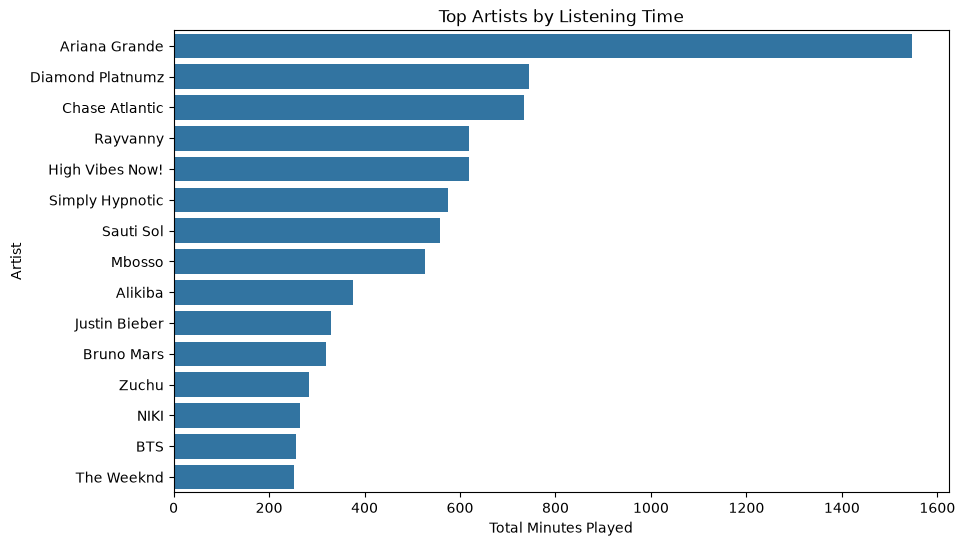

In [32]:
# Top Artists
top_artists = (
    streaming_df
    .groupby("artist_name")
    .agg(
        play_count=("track_name", "count"),
        total_minutes=("minutes_played", "sum"),
        unique_tracks=("track_name", "nunique")
    )
    .reset_index()
    .sort_values("total_minutes", ascending=False)
    .head(15)
)

top_artists
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_artists,
    x="total_minutes",
    y="artist_name"
)

plt.title("Top Artists by Listening Time")
plt.xlabel("Total Minutes Played")
plt.ylabel("Artist")
plt.show()

## 7. Listening By Hour Of Day
### Listening Patterns by Hour of Day
Aggregate total minutes played by hour of day (0–23) and plot it as a line chart to reveal when during the day listening peaks (e.g. mornings,evenings).

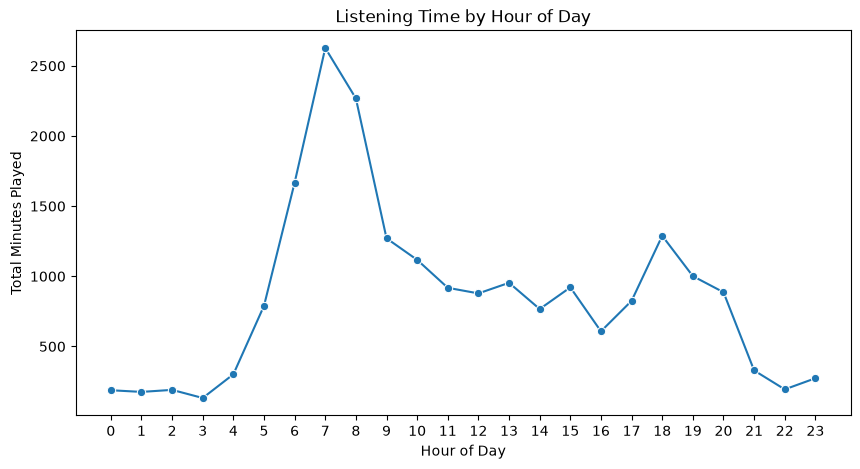

In [34]:
# Listening By Hour Of Day
hourly_listening = (
    streaming_df
    .groupby("hour")
    .agg(
        play_count=("track_name", "count"),
        total_minutes=("minutes_played", "sum")
    )
    .reset_index()
)

hourly_listening
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=hourly_listening,
    x="hour",
    y="total_minutes",
    marker="o"
)

plt.title("Listening Time by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Total Minutes Played")
plt.xticks(range(0, 24))
plt.show()

## 8. Listening By Day Of Week
### Listening Patterns by Weekday
Aggregate total minutes played by weekday, reorder the days Monday→Sunday and plot as a bar chart to see which days have the most listening activity.

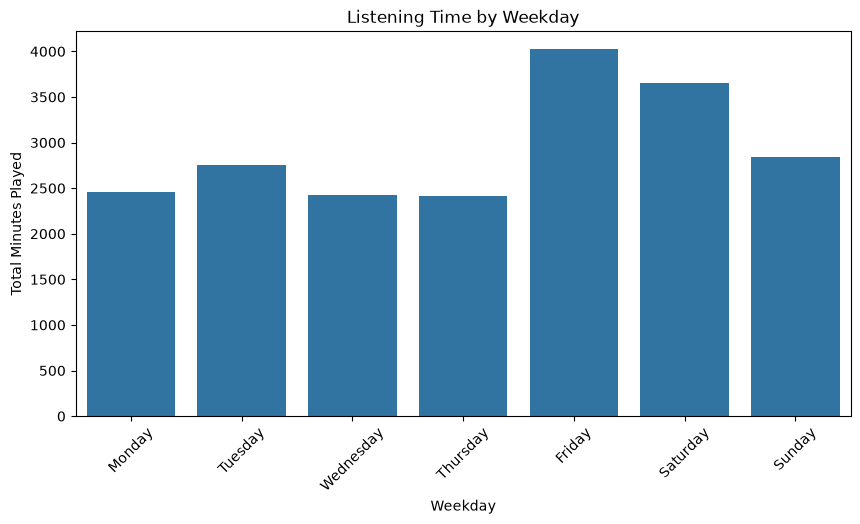

In [35]:
# Listening By Day Of Week
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_listening = (
    streaming_df
    .groupby("weekday")
    .agg(
        play_count=("track_name", "count"),
        total_minutes=("minutes_played", "sum")
    )
    .reindex(weekday_order)
    .reset_index()
)

weekday_listening
plt.figure(figsize=(10, 5))
sns.barplot(
    data=weekday_listening,
    x="weekday",
    y="total_minutes"
)

plt.title("Listening Time by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Total Minutes Played")
plt.xticks(rotation=45)
plt.show()

## 9. Listening Over Time
### Listening Trend Over Time
Aggregate total minutes played by calendar date and plot the trend as a line chart to see how listening volume has changed day-to-day across the whole history.

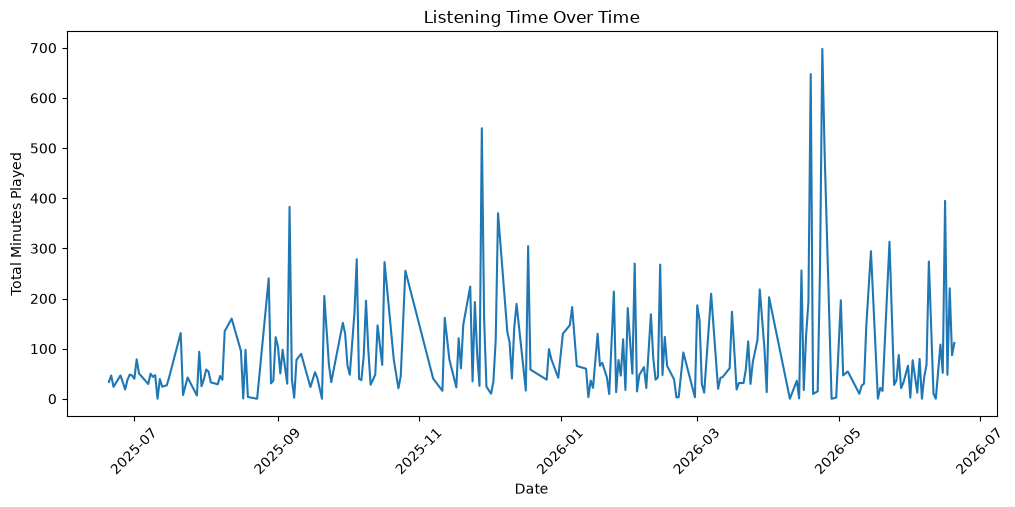

In [41]:
#Listening Over Time
daily_listening = (
    streaming_df
    .groupby("date")
    .agg(
        play_count=("track_name", "count"),
        total_minutes=("minutes_played", "sum")
    )
    .reset_index()
)

daily_listening.head()
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=daily_listening,
    x="date",
    y="total_minutes"
)

plt.title("Listening Time Over Time")
plt.xlabel("Date")
plt.ylabel("Total Minutes Played")
plt.xticks(rotation=45)
plt.show()


## 10. Skipped Tracks Analysis
### Skip Rate and Most-Skipped Tracks
Flag any play under 30 seconds (30,000 ms) as a "skip," calculate the overall skip rate as a percentage and list the 15 tracks that were skipped most often.

In [44]:
# Skipped Tracks Analysis
streaming_df["is_skip"] = streaming_df["ms_played"] < 30000

skip_rate = streaming_df["is_skip"].mean() * 100
print("Skip rate:", round(skip_rate, 2), "%")

most_skipped = (
    streaming_df[streaming_df["is_skip"]]
    .groupby(["track_name", "artist_name"])
    .size()
    .reset_index(name="skip_count")
    .sort_values("skip_count", ascending=False)
    .head(15)
)

most_skipped


Skip rate: 27.38 %


,track_name,artist_name,skip_count
870,Nobody Gets Me,SZA,10
885,Number One (feat. Zuchu),Rayvanny,10
1279,Waache Waoane,Chege,9
1115,Stuck with U (with Justin Bieber),Ariana Grande,9
1239,Ukimuona,Diamond Platnumz,8
467,I Like U,NIKI,8
912,"One Of The Girls (with JENNIE, Lily Rose Depp)",The Weeknd,8
224,Come Through (feat. Chris Brown),H.E.R.,8
1387,luther (with sza),Kendrick Lamar,8
1083,Slowly,Meddy,8


## 11. Playlist Analysis
### Playlist Sizes
Count how many unique playlists exist, then calculate and plot the number of tracks contained in each playlist, sorted from largest to smallest.

c:\Users\class\OneDrive\Documents\Spotify Recommendation System\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


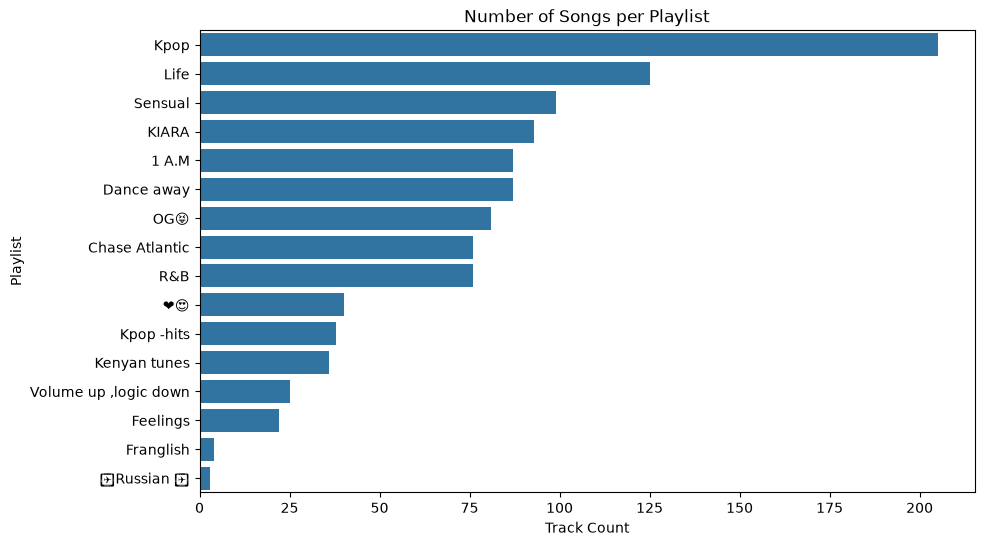

In [52]:
# Playlist Analysis
playlist_df["playlist_name"].nunique()
songs_per_playlist = (
    playlist_df
    .groupby("playlist_name")
    .agg(track_count=("track_name", "count"))
    .reset_index()
    .sort_values("track_count", ascending=False)
)

songs_per_playlist

plt.figure(figsize=(10, 6))
sns.barplot(
    data=songs_per_playlist,
    x="track_count",
    y="playlist_name"
)

plt.title("Number of Songs per Playlist")
plt.xlabel("Track Count")
plt.ylabel("Playlist")
plt.show()

## 12. Library Analysis
### Saved vs. Unsaved Listening Behavior
Compare tracks that are saved to the library against those that aren't,looking at average play count and average minutes played for each group and plot the difference in average listening time.

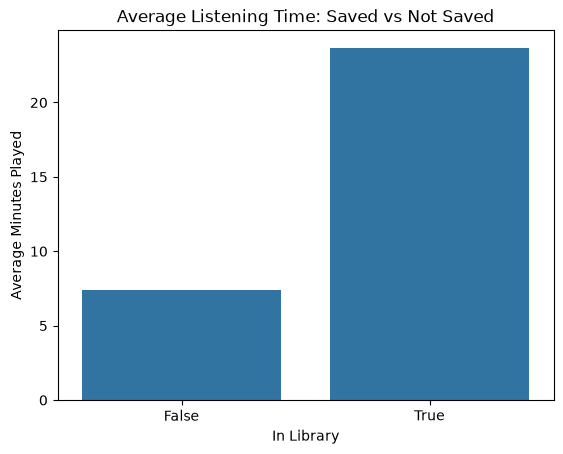

In [53]:
# Library Analysis
library_df["track_name"].nunique()
tracks_df["in_library"].value_counts()

saved_vs_unsaved = (
    tracks_df
    .groupby("in_library")
    .agg(
        avg_play_count=("play_count", "mean"),
        avg_minutes=("total_minutes_played", "mean"),
        track_count=("track_key", "count")
    )
    .reset_index()
)

saved_vs_unsaved

sns.barplot(
    data=saved_vs_unsaved,
    x="in_library",
    y="avg_minutes"
)

plt.title("Average Listening Time: Saved vs Not Saved")
plt.xlabel("In Library")
plt.ylabel("Average Minutes Played")
plt.show()

## 13. Playlist and Listening Relationship
### Playlisted Tracks Ranked by Listening Time
Filter to tracks that appear in at least one playlist and sort them by total minutes played, to see whether playlisted songs are also the ones actually listened to the most.

In [56]:
# Playlist and Listening Relationship
playlist_listening = tracks_df[
    tracks_df["playlist_count"] > 0
].sort_values("total_minutes_played", ascending=False)

playlist_listening.head(20)



,track_key,artist_name,track_name,play_count,total_minutes_played,first_played,last_played,playlist_count,playlists,in_library
2006,"the weeknd - one of the girls (with jennie, li...",The Weeknd,"One Of The Girls (with JENNIE, Lily Rose Depp)",45,140.794800,2025-07-09 21:13:00,2026-06-18 11:26:00,4,"1 A.M, Life, R&B, ❤️😍",False
866,h.e.r. - come through (feat. chris brown),H.E.R.,Come Through (feat. Chris Brown),41,108.426483,2025-06-29 19:42:00,2026-05-23 14:50:00,4,"Dance away, Life, R&B, Sensual",True
125,ariana grande - into you,Ariana Grande,Into You,31,104.640050,2025-06-30 20:40:00,2026-06-20 09:00:00,3,"Life, Sensual, ❤️😍",True
1686,rihanna - kiss it better,Rihanna,Kiss It Better,28,101.555100,2025-07-07 20:51:00,2026-06-20 08:23:00,3,"Life, Sensual, ❤️😍",True
1052,justin bieber - confident,Justin Bieber,Confident,28,99.720850,2025-07-02 16:13:00,2026-06-16 09:15:00,2,"Life, Sensual",True
1456,niki - lowkey,NIKI,lowkey,39,95.309083,2025-07-02 19:58:00,2026-06-16 08:22:00,3,"Feelings, Life, R&B",True
391,cardi b - please me,Cardi B,Please Me,33,94.198267,2025-07-21 07:03:00,2026-06-20 10:00:00,4,"Life, R&B, Sensual, ❤️😍",True
156,ariana grande - stuck with u (with justin bieber),Ariana Grande,Stuck with U (with Justin Bieber),36,94.071850,2025-06-20 20:50:00,2026-06-14 16:01:00,2,"Life, R&B",True
642,diamond platnumz - kuna,Diamond Platnumz,Kuna,13,85.422017,2025-11-28 09:45:00,2026-03-16 08:19:00,1,OG😝,True
1854,sisqo - thong song,Sisqo,Thong Song,24,85.334733,2025-09-06 10:19:00,2026-06-15 12:26:00,3,"Life, R&B, Volume up ,logic down",True


## 14. Rarely listened tracks 
### Playlisted but Never Played
Identify tracks that were added to a playlist but have zero recorded plays in the streaming history — songs that were saved with intent but never actually listened to.

In [58]:
# Rarely listened tracks
playlist_not_played = tracks_df[
    (tracks_df["playlist_count"] > 0) &
    (tracks_df["play_count"] == 0)
]

playlist_not_played.head()

,track_key,artist_name,track_name,play_count,total_minutes_played,first_played,last_played,playlist_count,playlists,in_library
